# Metrics

In [20]:
#Necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

## Fasttext LID

In [25]:
df = pd.read_csv("data/outputs/fasttext_may_fixed.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,fasttext_lid
0,0,0,post_0001,1,0,yabancı,TR,NONE,O,TR
1,1,1,post_0001,1,1,bir,TR,NONE,O,TR
2,2,2,post_0001,1,2,hocamızın,TR,NONE,O,TR
3,3,3,post_0001,1,3,yarı,TR,NONE,O,TR
4,4,4,post_0001,1,4,şaka,TR,NONE,O,TR


In [6]:
df['lid'].value_counts()

lid
TR           3860
EN            622
NE            346
MIXED          76
AMBIGUOUS      28
OTHER           4
Name: count, dtype: int64

In [160]:
df['ner'].value_counts()

ner
O (no label)    1071
B-ORG             12
I-MISC            12
B-PER              9
I-ORG              4
B-MISC             3
I-PER              2
B-LOC              1
Name: count, dtype: int64

In [163]:
df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "ner"], inplace=True)
df.head()

,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,fasttext_lid
0,post_0001,1,0,yabancı,TR,NONE,TR
1,post_0001,1,1,bir,TR,NONE,TR
2,post_0001,1,2,hocamızın,TR,NONE,TR
3,post_0001,1,3,yarı,TR,NONE,TR
4,post_0001,1,4,şaka,TR,NONE,TR


In [164]:
df["lid"].value_counts()

lid
TR       859
EN       210
OTHER     23
MIXED     22
Name: count, dtype: int64

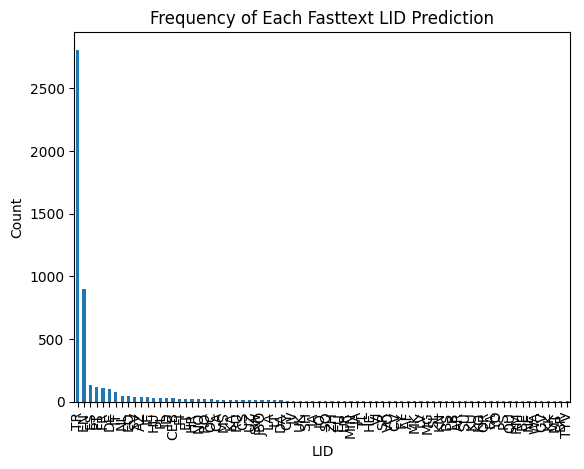

In [7]:
df['fasttext_lid'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Fasttext LID Prediction')
plt.xlabel('LID')
plt.ylabel('Count')
plt.show()

In [8]:
df["fasttext_lid"].value_counts()

fasttext_lid
TR     2809
EN      900
ES      133
PT      113
FR      107
       ... 
GV        1
KK        1
MT        1
BR        1
TYV       1
Name: count, Length: 78, dtype: int64

In [15]:
df["fasttext_lid"].nunique()

3

In [16]:
mismatched_rows = df[df['lid'] != df['fasttext_lid']]

In [17]:
error_counts = mismatched_rows.groupby(['lid', 'fasttext_lid']).size().reset_index(name='count')
error_counts = error_counts.sort_values(by='count', ascending=False)

print("Top 10 Misprediction Pairs:")
print(error_counts.head(10))

Top 10 Misprediction Pairs:
          lid fasttext_lid  count
13         TR        OTHER    998
12         TR           EN    445
10         NE           TR    172
4          EN           TR    156
3          EN        OTHER    104
9          NE        OTHER     94
8          NE           EN     80
7       MIXED           TR     46
6       MIXED        OTHER     23
2   AMBIGUOUS           TR     14


### Replace Misc languages with "Other" Label

In [26]:
#if not EN or TR, put OTHER
def lang(pred):
    if pred != "EN" and pred != "TR":
        return "OTHER"
    else:
        return pred
    
df["fasttext_lid"] = df["fasttext_lid"].apply(lang)
df["fasttext_lid"].value_counts()


fasttext_lid
TR       2809
OTHER    1229
EN        900
Name: count, dtype: int64

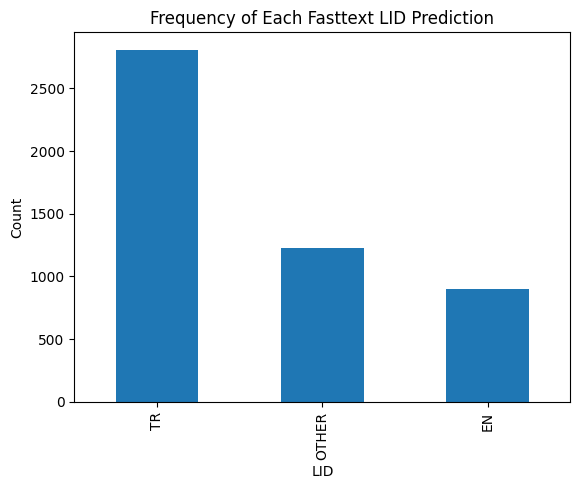

In [18]:
df['fasttext_lid'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Fasttext LID Prediction')
plt.xlabel('LID')
plt.ylabel('Count')
plt.show()

In [14]:
df['fasttext_lid'].value_counts()

fasttext_lid
TR       2809
OTHER    1229
EN        900
Name: count, dtype: int64

In [24]:
df[df.isna().any(axis=1)]

,Unnamed: 0.1,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,fasttext_lid
4848,4848,4848,post_058,1,11,web,NaN,NONE,O,OTHER
4849,4849,4849,post_058,1,12,store'dan,NaN,MIXED,O,TR


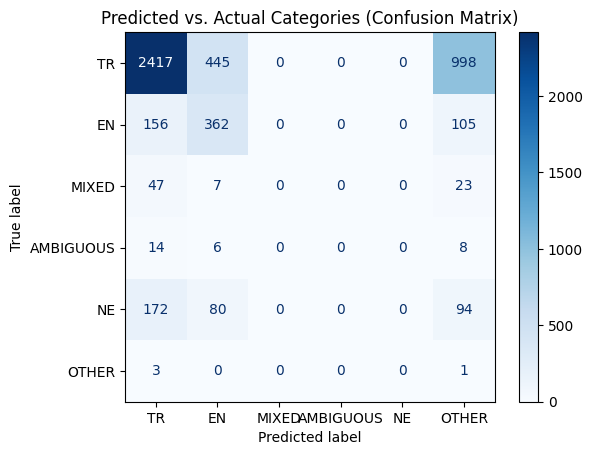

In [27]:
cm = confusion_matrix(df['lid'], df['fasttext_lid'], labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [28]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

macro_f1 = f1_score(df["lid"], df["fasttext_lid"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")


Overall Macro F1 Score: 0.2003



In [177]:
f1_per_class = f1_score(df["lid"], df["fasttext_lid"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.78139535 0.         0.         0.80603153]



In [29]:
print("Classification Report:")
print(classification_report(df["lid"], df["fasttext_lid"]))

Classification Report:
              precision    recall  f1-score   support

   AMBIGUOUS       0.00      0.00      0.00        28
          EN       0.40      0.58      0.48       623
       MIXED       0.00      0.00      0.00        77
          NE       0.00      0.00      0.00       346
       OTHER       0.00      0.25      0.00         4
          TR       0.86      0.63      0.72      3860

    accuracy                           0.56      4938
   macro avg       0.21      0.24      0.20      4938
weighted avg       0.72      0.56      0.63      4938



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [135]:
mismatched_rows = df[df['lid'] != df['fasttext_lid']]

In [136]:
print(mismatched_rows[mismatched_rows['lid'] == "EN"])

         doc_id  sent_id  tok_id      token lid borrowed_suffix fasttext_lid
16    post_0001        1      16     simple  EN            NONE        OTHER
188   post_0008        1       0       deep  EN            NONE        OTHER
249   post_0010        2       0       poly  EN            NONE        OTHER
299   post_0013        1       5  amusement  EN            NONE        OTHER
303   post_0013        1      10         vb  EN            NONE        OTHER
326   post_0014        1       3     create  EN            NONE        OTHER
328   post_0014        1       6   mantralı  EN            NONE           TR
390   post_0016        1       6     london  EN            NONE        OTHER
394   post_0016        1      10        con  EN            NONE        OTHER
397   post_0016        1      13     icinde  EN            NONE        OTHER
399   post_0016        1      15     london  EN            NONE        OTHER
403   post_0016        1      19        con  EN            NONE        OTHER

In [137]:
confusion_matrix = pd.crosstab(mismatched_rows['lid'], mismatched_rows['fasttext_lid'])

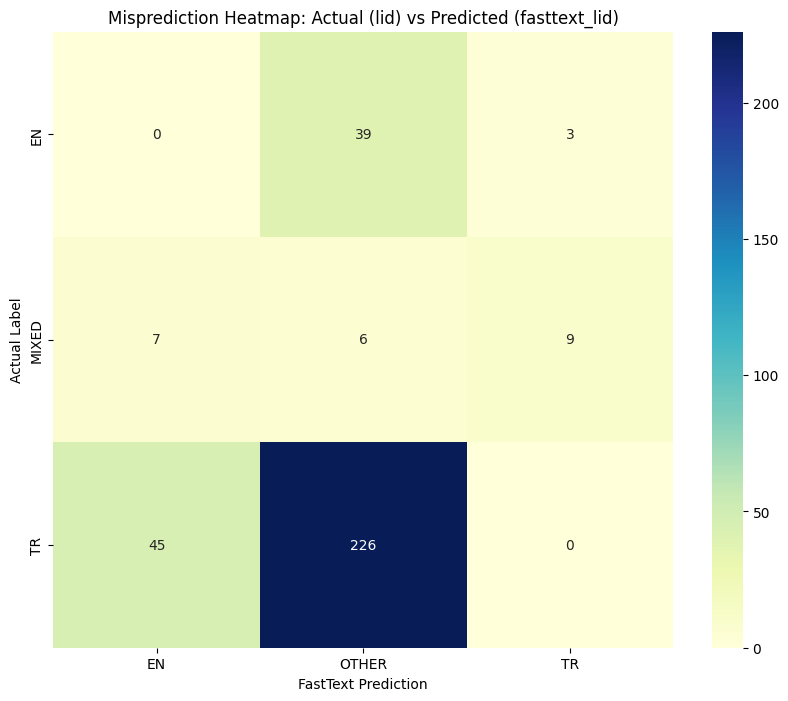

In [138]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (lid) vs Predicted (fasttext_lid)')
plt.ylabel('Actual Label')
plt.xlabel('FastText Prediction')
plt.show()

### Removing "Mixed" prediction errors if TR or EN predicted

In [180]:
mask = (df['lid'] == 'MIXED') & (df['fasttext_lid'].isin(['TR', 'EN']))

# Apply the change
df.loc[mask, 'fasttext_lid'] = 'MIXED'

In [181]:
cm = confusion_matrix(df['lid'], df['fasttext_lid'], labels=["TR", "EN", "MIXED", "OTHER"])

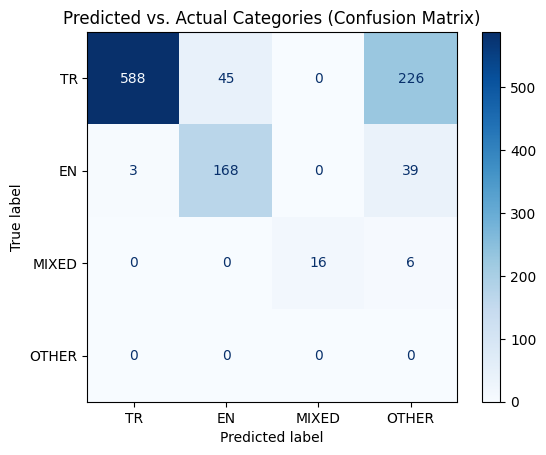

In [182]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TR", "EN", "MIXED", "OTHER"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [183]:

macro_f1 = f1_score(df["lid"], df["fasttext_lid"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")


Overall Macro F1 Score: 0.6119



In [184]:
f1_per_class = f1_score(df["lid"], df["fasttext_lid"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.79432624 0.84210526 0.         0.81103448]



In [185]:
print("Classification Report:")
print(classification_report(df["lid"], df["fasttext_lid"]))

Classification Report:
              precision    recall  f1-score   support

          EN       0.79      0.80      0.79       210
       MIXED       1.00      0.73      0.84        22
       OTHER       0.00      0.00      0.00         0
          TR       0.99      0.68      0.81       859

    accuracy                           0.71      1091
   macro avg       0.70      0.55      0.61      1091
weighted avg       0.96      0.71      0.81      1091



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.